# Task 8 

Same pipeline as Task 7, but now I'm looping over four values of that 0.7 multiplier to
see what it actually controls.

What the number means: `0.7 * dist.max()` keeps only pixels that are at least 70% as deep
inside an object as the deepest point anywhere in the image. Lower it and the markers get
bigger; raise it and they shrink.

Everything else stays exactly the same so only one thing is changing.

Testing 0.3, 0.5, 0.7 and 0.9.

Threshold: 0.3 | Foreground markers: 2 | Separated regions: 2
Threshold: 0.5 | Foreground markers: 24 | Separated regions: 24
Threshold: 0.7 | Foreground markers: 24 | Separated regions: 24
Threshold: 0.9 | Foreground markers: 24 | Separated regions: 24


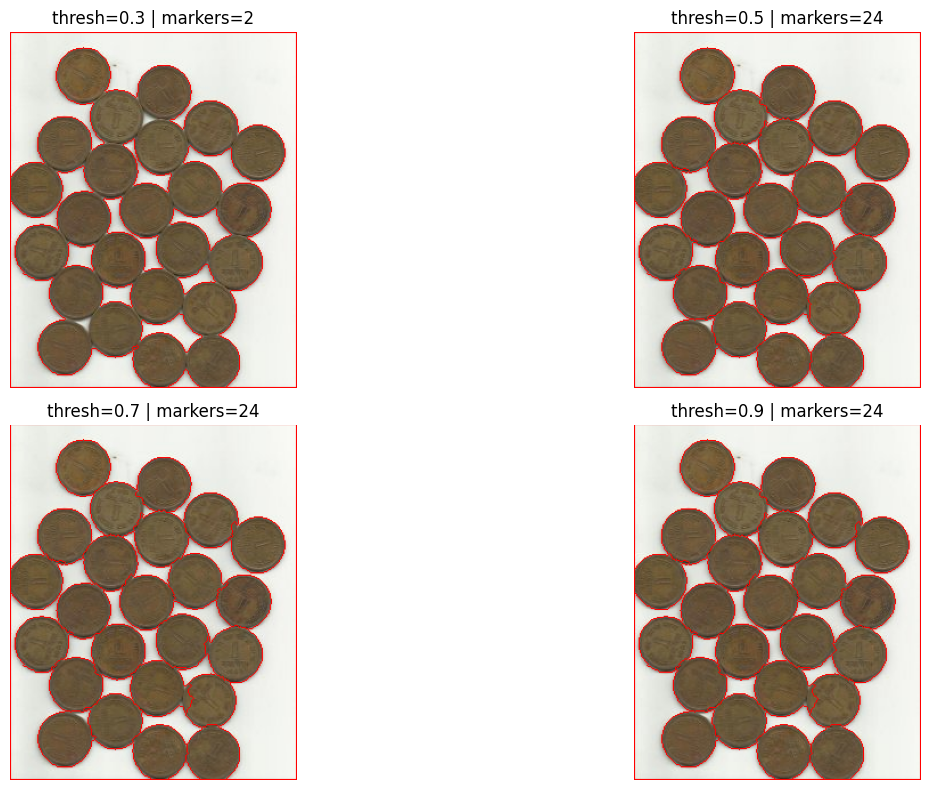

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("water_coins.jpg")

if img is None:
    print("Error: water_coins.jpg not found")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 0, 255,
                              cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
    sure_bg = cv2.dilate(opening, kernel, iterations=3)
    dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

    # Four experiments with different distance thresholds
    values = [0.3, 0.5, 0.7, 0.9]
    results = []
    titles = []

    for v in values:
        _, sure_fg = cv2.threshold(dist, v * dist.max(), 255, 0)
        sure_fg = np.uint8(sure_fg)

        unknown = cv2.subtract(sure_bg, sure_fg)

        count, markers = cv2.connectedComponents(sure_fg)
        markers = markers + 1
        markers[unknown == 255] = 0

        found = count - 1
        markers = cv2.watershed(img, markers)

        # Count how many regions survived the watershed
        regions = len(np.unique(markers)) - 2   # drop background and -1

        out = img.copy()
        out[markers == -1] = [0, 0, 255]

        results.append(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
        titles.append("thresh=" + str(v) + " | markers=" + str(found))

        print("Threshold:", v, "| Foreground markers:", found,
              "| Separated regions:", regions)

    plt.figure(figsize=(16, 8))
    for i in range(4):
        plt.subplot(2, 2, i + 1)
        plt.imshow(results[i])
        plt.title(titles[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

### Results

| Experiment | Distance Threshold | Foreground Markers | Separated Regions | Observed Result |
|---|---|---|---|---|
| 1 | 0.3 | | | Markers merge, touching coins stay joined |
| 2 | 0.5 | | | Good separation |
| 3 | 0.7 | | | Clean separation |
| 4 | 0.9 | | | Markers shrink or vanish, some coins missed |

(filling the blank columns from the printed output)

**What's going on**

At a **low** threshold the sure foreground blobs are big, so where two coins touch the
blobs bump into each other and merge. Two coins end up sharing one marker, and watershed
has no reason to split them since it only separates different markers.

At a **high** threshold the blobs shrink so much that the smaller coins lose their marker
completely. Those coins get swallowed into a neighbouring region or just counted as
background.

**Best range: 0.5 to 0.7.** Big enough that every coin keeps its own marker, small enough
that no two coins end up sharing one.

This is why the distance transform stage matters so much. The threshold on it is basically
deciding "how much of each object am I confident about", and watershed can only ever
produce as many regions as there are markers going in.